## Pup Inflation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

seaborn.set()

In [3]:
df = pd.read_csv("dog_rates_tweets.csv", parse_dates=['created_at'])

In [4]:
import re
# Rating n/10
n10 = r'(\d+(\.\d+)?)/10'
# Extract rating from 'text', to float
df['rating'] = df['text'].str.extract(n10).astype(float)[0]

In [5]:
# Exclude tweets that don't have rating = keep not Na
df = df[df['rating'].notna()]
# Remove outlier: rate > 25 = keep <= 25
df = df[df['rating'] <= 25]

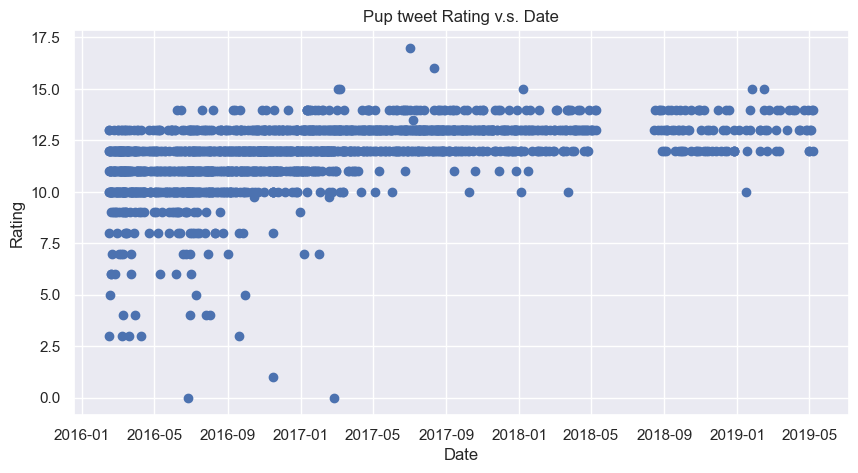

In [6]:
# Plot: date v.s. rating
plt.figure(figsize=(10, 5))
plt.scatter(df['created_at'], df['rating'])
plt.title("Pup tweet Rating v.s. Date")
plt.xlabel('Date')
plt.ylabel('Rating')
plt.show()

### Linear Fitting

In [8]:
from scipy import stats

In [9]:
# Have a to_timestamp function
def to_timestamp(date):
    return date.timestamp()

In [10]:
# Create a 'timestamp' coln
df['timestamp'] = df['created_at'].apply(to_timestamp)

# Linregress to get slope and intercept for best fit line
# modify from: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html
# Apply linear regression
res = stats.linregress(df['timestamp'], df['rating'])
# Best Fit line
df['fit_rating'] = res.slope * df['timestamp'] + res.intercept
df['fit_rating'].dtype

dtype('float64')

## Results

In [12]:
df

,id,created_at,text,rating,timestamp,fit_rating
2,994363623421153280,2018-05-09 23:48:56,This is Louie. He has misplaced his Cheerio. W...,14.0,1.525910e+09,13.185763
7,993889039714578432,2018-05-08 16:23:07,This is Manny. He hasn’t seen your croissant. ...,13.0,1.525797e+09,13.181785
8,993629544463642624,2018-05-07 23:11:58,This is Libby. She leap. 14/10\n(IG: libbythef...,14.0,1.525735e+09,13.179609
24,992198572664860672,2018-05-04 00:25:48,This is Rosie. She thought Coachella was this ...,13.0,1.525394e+09,13.167614
30,991744041351090177,2018-05-02 18:19:39,This is Riley. He’ll be your chauffeur this ev...,13.0,1.525285e+09,13.163804
...,...,...,...,...,...,...
7363,1032725635888803841,2018-08-23 20:25:53,This is Noodles. He had brain surgery earlier ...,14.0,1.535056e+09,13.507338
7369,1032310288652152832,2018-08-22 16:55:26,This is Pingo and Nina. They are believed to b...,14.0,1.534957e+09,13.503856
7381,1031696422813544448,2018-08-21 00:16:09,This is Nikita. She got caught in some wild fl...,13.0,1.534811e+09,13.498710
7431,1029767403545288706,2018-08-15 16:30:55,This is Winston. He came home for the first ti...,14.0,1.534351e+09,13.482540


In [13]:
# print best-fit line's slope, intercept
print(f"Best-fit line,\n  slope: {res.slope}\n  intercept: {res.intercept}")

Best-fit line,
  slope: 3.515929974847721e-08
  intercept: -40.46415480898916


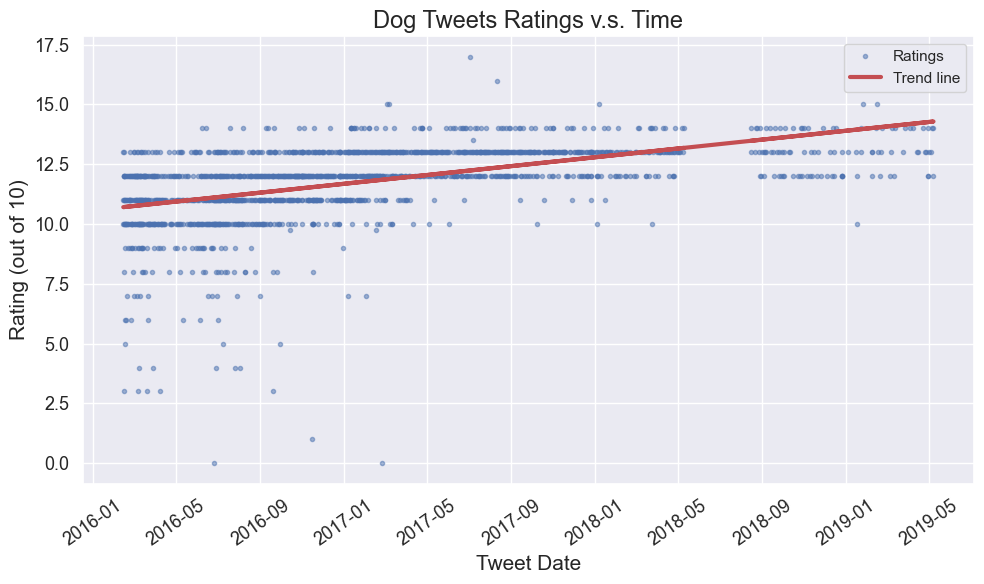

In [82]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(df['created_at'], df['rating'], 'b.', alpha=0.5, label='Ratings')
plt.plot(df['created_at'], df['fit_rating'], 'r-', linewidth=3, label='Trend line')

# Plot designs
plt.title("Dog Tweets Ratings v.s. Time", fontsize=17)
plt.xlabel('Tweet Date', fontsize=15)
plt.ylabel('Rating (out of 10)', fontsize=15)

plt.xticks(rotation=35, fontsize=13)
plt.yticks(fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("rate.png")
plt.show()

## Exercise 7

In [16]:
res.pvalue

1.5139606492959894e-106

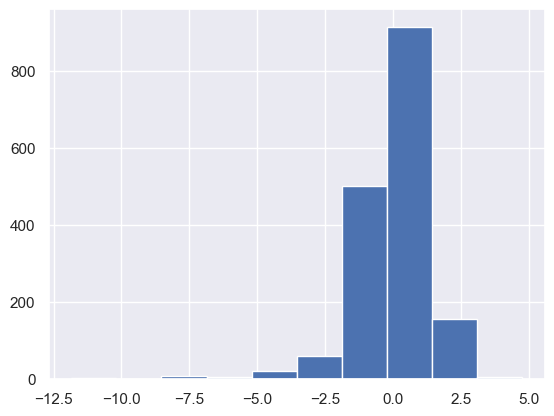

In [17]:
plt.hist(df['rating'] - df['fit_rating'])
plt.show()

### e12 Report's graph

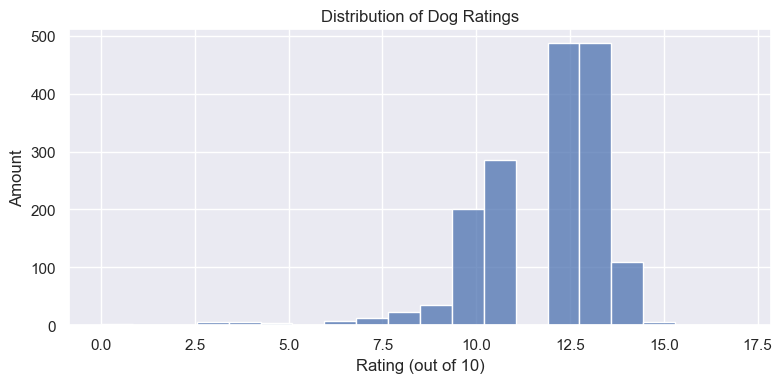

In [80]:
plt.figure(figsize=(8, 4))
seaborn.histplot(df['rating'], bins=20)
plt.title("Distribution of Dog Ratings")
plt.xlabel("Rating (out of 10)")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig("rating_histogram.png")
plt.show()